In [35]:
import os
import pickle
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from neurocore.visualization import plot_curve, plot_permutation_result
from neurocore.visualization.common import add_event_line,create_figure
from neurocore.stats import permutation_test_vs_baseline
from neurocore.stats.permutation import permutation_test_between_groups
from itertools import combinations
from scipy.cluster.hierarchy import leaves_list
from scipy.spatial.distance import pdist, cdist, squareform
from tqdm import tqdm

In [36]:
DECISION_MAKING_INDEX = 100
IN_INDEX = 150
OUT_INDEX = 450
NUM_TIMEPOINTS = 600

In [37]:
with open(f'./data/DA/processed/DA_dataset.pkl', 'rb') as f:
    DAdataset = pickle.load(f)
df = DAdataset.copy()

In [38]:
df = df[(df['mouse_group'] == 'OLD_MH_6')
        & (df['phase_id']!='baseline')
        & (df['brain_region'] == 'mPFC')
        ]
df = df.dropna(subset=['warped_signal'])

In [39]:
df.columns

Index(['mouse_id', 'phase_id', 'trial_id', 'cum_trial_id', 'mouse_group',
       'prev_choice', 'current_choice', 'next_choice', 't_time_start',
       't_time_end', 'dm_time', 'i_time', 'xb_time', 'o_time', 'r_time',
       'd_time', 'opponent_id', 'day_meet_this_opponent_times',
       'cumulative_meet_this_opponent_times', 'brain_region', 'df_f',
       'warped_signal', 'cross_trial_warped_signal', 'event_dff_out',
       'whole_trial_time', 'same_choice_in_to_last_out', 'velocity',
       'whole_trial_velocity'],
      dtype='str')

In [40]:
def analyze_three_choice_patterns():
    """分析三选择模式(prev-current-next)的DA信号"""
    three_choice_patterns = [
        f"{prev}-{current}-{next}"
        for prev in ['w', 'g']
        for current in ['w', 'g']
        for next in ['w', 'g']
    ]

    pattern_signals = []
    pattern_records = []
    mouse_pattern_records = []

    # 每个模式内先按 mouse_id 对 trial 信号求平均
    for pattern in three_choice_patterns:
        prev_choice, current_choice, next_choice = pattern.split('-')

        pattern_data = df[
            (df['prev_choice'] == prev_choice) &
            (df['current_choice'] == current_choice) &
            (df['next_choice'] == next_choice)
        ]

        mouse_signals = []
        for mouse_id, mouse_pattern_data in pattern_data.groupby('mouse_id'):
            signals = np.stack(mouse_pattern_data['warped_signal'].values)
            mouse_signal = np.nanmean(signals, axis=0)
            mouse_signals.append(mouse_signal)
            mouse_pattern_records.extend([
                {
                    'mouse_id': mouse_id,
                    'pattern': pattern,
                    'n_trials': len(mouse_pattern_data),
                    'timepoint': tp - IN_INDEX,
                    'signal': val
                }
                for tp, val in enumerate(mouse_signal)
            ])

        mouse_signals = np.stack(mouse_signals)
        signal_segment = np.nanmean(mouse_signals, axis=0)
        pattern_signals.append((pattern, signal_segment))
        pattern_records.extend([
            {
                'pattern': pattern,
                'n_mice': len(mouse_signals),
                'timepoint': tp - IN_INDEX,
                'signal': val
            }
            for tp, val in enumerate(signal_segment)
        ])

    signal_dataframe = pd.DataFrame({
        'pattern': [x[0] for x in pattern_signals],
        'signal': [x[1] for x in pattern_signals]
    })
    pd.DataFrame(pattern_records).to_csv(('./results/DA_choice_choice_choice_heatmap/three_choice_pattern_signals.csv'), index=False)
    pd.DataFrame(mouse_pattern_records).to_csv(('./results/DA_choice_choice_choice_heatmap/three_choice_pattern_mouse_signals.csv'), index=False)

    signal_matrix = np.array(signal_dataframe['signal'].tolist())
    Z = linkage(signal_matrix, method="ward")

    # 生成clustermap
    g = sns.clustermap(signal_matrix, row_linkage=Z, col_cluster=False,
                        yticklabels=signal_dataframe['pattern'].tolist(),
                        cmap="bwr", figsize=(10, 8), vmin=-0.4, vmax=0.2,)


    # 设置横轴
    ax = g.ax_heatmap
    xticks = np.arange(0, 601, 50)
    xlabels = np.arange(-150, 451, 50)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel("Time points")

    # 事件标记线
    ax.axvline(x=IN_INDEX, color='k', linestyle='--')
    ax.axvline(x=OUT_INDEX, color='k', linestyle='--')
    ax.axvline(x=DECISION_MAKING_INDEX, color='k', linestyle='--')
    ax.set_title("Mouse-averaged DA Signal Clustering Heatmap")

    # 优化dendrogram
    g.ax_row_dendrogram.clear()
    dendrogram(Z, orientation="left", ax=g.ax_row_dendrogram, color_threshold=None, above_threshold_color="black", link_color_func=lambda k: "black")

    g.ax_row_dendrogram.set_xticks([])
    g.ax_row_dendrogram.set_yticks([])
    g.ax_row_dendrogram.set_frame_on(False)
    g.ax_row_dendrogram.grid(False)

    for line in g.ax_row_dendrogram.get_lines():
        line.set_linewidth(2.0)

    # 添加比例尺
    ax_den = g.ax_row_dendrogram
    x_min, x_max = ax_den.get_xlim()
    scale_length = (x_max - x_min) * 0.2
    scale_value = round(scale_length, 2)
    y_pos = (ax_den.get_ylim()[0] + ax_den.get_ylim()[1]) / 12

    ax_den.plot([x_min + 0.05 * (x_max - x_min), x_min + 0.05 * (x_max - x_min) + scale_length], [y_pos, y_pos], color="k", lw=2)
    ax_den.plot([x_min + 0.05 * (x_max - x_min)]*2, [y_pos-1, y_pos+1], color="k", lw=2)
    ax_den.plot([x_min + 0.05 * (x_max - x_min) + scale_length]*2, [y_pos-1, y_pos+1], color="k", lw=2)
    ax_den.text(x_min + 0.05 * (x_max - x_min) + scale_length/2, y_pos+2, f"{-scale_value} distance", ha="center", va="bottom", color="k")

    plt.savefig(("./results/DA_choice_choice_choice_heatmap/ccc_clustermap.pdf"), format="pdf")
    plt.show()

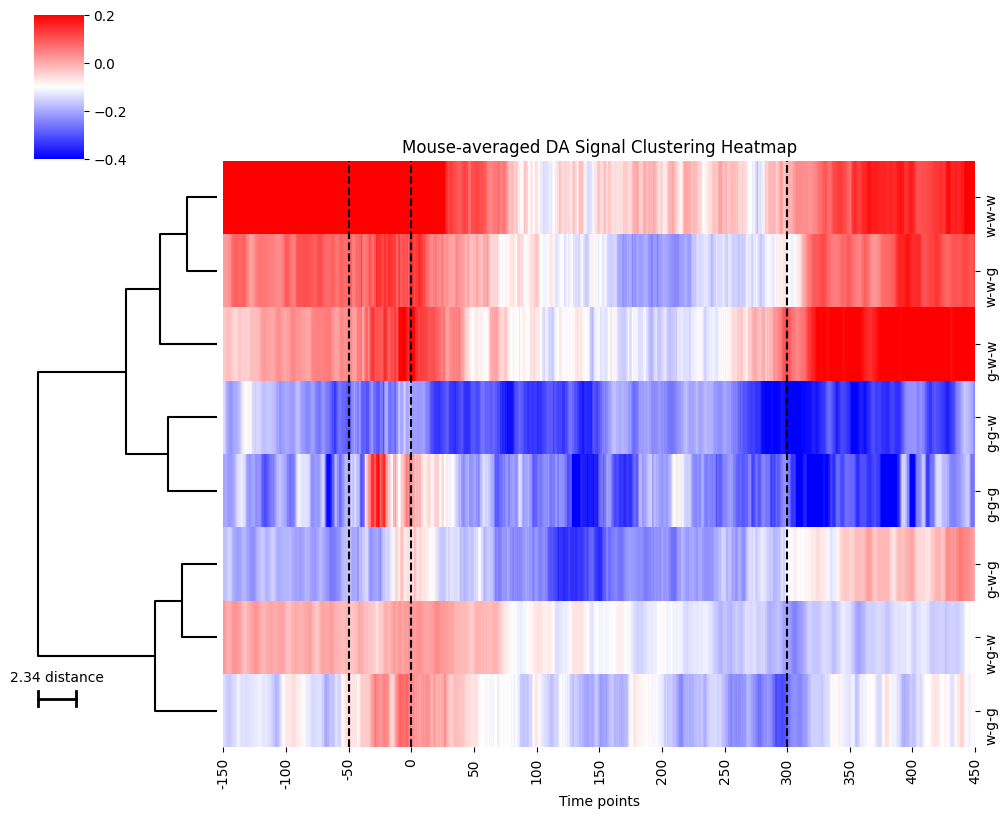

In [41]:
analyze_three_choice_patterns()

In [42]:
from statsmodels.stats.multitest import multipletests

Permutation tests: 100%|██████████| 28/28 [00:00<00:00, 95.11it/s]


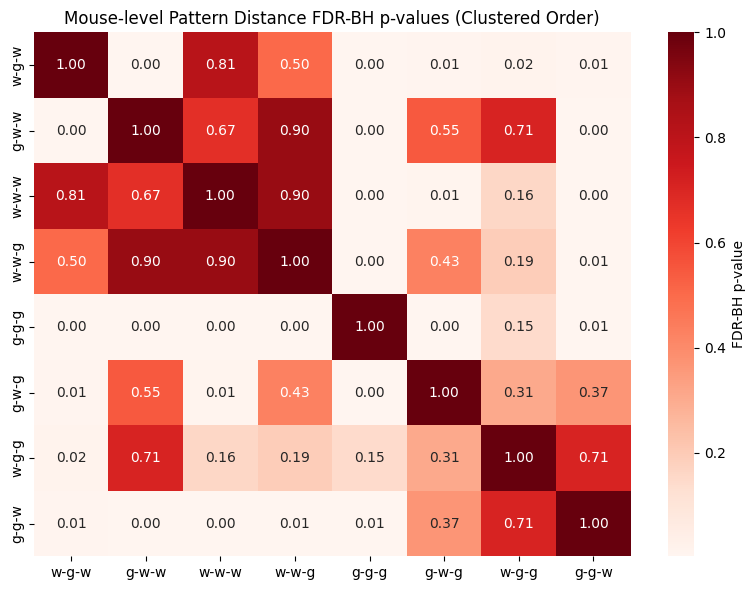

w-w-w: n_mice=6, n_trials=69, mean_intra_distance=6.9999
w-w-g: n_mice=6, n_trials=101, mean_intra_distance=6.7139
w-g-w: n_mice=6, n_trials=155, mean_intra_distance=5.1131
w-g-g: n_mice=6, n_trials=41, mean_intra_distance=9.4397
g-w-w: n_mice=6, n_trials=103, mean_intra_distance=7.3249
g-w-g: n_mice=6, n_trials=102, mean_intra_distance=6.8763
g-g-w: n_mice=6, n_trials=42, mean_intra_distance=7.4586
g-g-g: n_mice=5, n_trials=12, mean_intra_distance=15.4975


In [43]:
THREE_CHOICE_RESULT_DIR = './results/DA_choice_choice_choice_heatmap'
os.makedirs(THREE_CHOICE_RESULT_DIR, exist_ok=True)

def permutation_test(distances, intra, n_permutations=1000):
    """两组距离的置换检验。"""
    distances = np.asarray(distances, dtype=float)
    intra = np.asarray(intra, dtype=float)
    assert len(distances) > 0, 'distances 为空，无法进行置换检验'
    assert len(intra) > 0, 'intra 为空，无法进行置换检验'
    assert np.isfinite(distances).all(), 'distances 包含非有限值'
    assert np.isfinite(intra).all(), 'intra 包含非有限值'

    combined = np.concatenate([distances, intra])
    n_distances = len(distances)
    observed_diff = distances.mean() - intra.mean()
    count = 0

    for _ in range(n_permutations):
        np.random.shuffle(combined)
        perm_dist = combined[:n_distances]
        perm_intra = combined[n_distances:]
        perm_diff = perm_dist.mean() - perm_intra.mean()
        if abs(perm_diff) >= abs(observed_diff):
            count += 1

    p_val = (count + 1) / (n_permutations + 1)
    return p_val

def benjamini_hochberg_correction(p_values):
    """Benjamini-Hochberg FDR 多重比较校正。"""
    p_values = np.asarray(p_values, dtype=float)

    assert len(p_values) > 0, 'p_values 为空，无法进行多重比较校正'
    assert np.isfinite(p_values).all(), 'p_values 包含非有限值'
    assert ((p_values >= 0) & (p_values <= 1)).all(), 'p_values 必须在 [0, 1] 范围内'

    _, adjusted_p_values, _, _ = multipletests(
        p_values,
        alpha=0.05,
        method='fdr_bh'
    )

    return adjusted_p_values

def analyze_three_choice_patterns_full_permutation(n_permutations=1000):
    """Mouse-level 三选择模式距离统计、两两置换检验和 p 值聚类热图。"""
    three_choice_patterns = [
        f"{prev}-{current}-{next}"
        for prev in ['w', 'g']
        for current in ['w', 'g']
        for next in ['w', 'g']
    ]

    signal_start, signal_end = 0, NUM_TIMEPOINTS - 1
    mouse_pattern_signals = []
    mouse_pattern_labels = []
    mouse_pattern_mouse_ids = []
    mouse_pattern_n_trials = []

    for pattern in three_choice_patterns:
        prev_choice, current_choice, next_choice = pattern.split('-')
        pattern_data = df[
            (df['prev_choice'] == prev_choice) &
            (df['current_choice'] == current_choice) &
            (df['next_choice'] == next_choice)
        ]

        for mouse_id, mouse_pattern_data in pattern_data.groupby('mouse_id'):
            signals = np.stack([
                np.asarray(signal[signal_start:signal_end], dtype=float)
                for signal in mouse_pattern_data['warped_signal']
            ])
            mouse_pattern_signals.append(signals.mean(axis=0))
            mouse_pattern_labels.append(pattern)
            mouse_pattern_mouse_ids.append(mouse_id)
            mouse_pattern_n_trials.append(len(mouse_pattern_data))

    mouse_pattern_signals = np.stack(mouse_pattern_signals)
    mouse_pattern_labels = np.asarray(mouse_pattern_labels)
    mouse_pattern_mouse_ids = np.asarray(mouse_pattern_mouse_ids)
    mouse_pattern_n_trials = np.asarray(mouse_pattern_n_trials)

    mouse_pattern_df = pd.DataFrame(
        mouse_pattern_signals,
        columns=[f'timepoint_{tp - IN_INDEX}' for tp in range(signal_start, signal_end)]
    )
    mouse_pattern_df.insert(0, 'n_trials', mouse_pattern_n_trials)
    mouse_pattern_df.insert(0, 'pattern', mouse_pattern_labels)
    mouse_pattern_df.insert(0, 'mouse_id', mouse_pattern_mouse_ids)
    mouse_pattern_df.to_csv(os.path.join(THREE_CHOICE_RESULT_DIR, '4.1_mouse_pattern_level_signals.csv'), index=False)

    pattern_stats = {}
    for pattern in three_choice_patterns:
        pattern_mouse_signals = mouse_pattern_signals[mouse_pattern_labels == pattern]
        pattern_n_trials = mouse_pattern_n_trials[mouse_pattern_labels == pattern]
        n_mice = len(pattern_mouse_signals)
        dist_matrix = squareform(pdist(pattern_mouse_signals, metric='euclidean'))
        mean_intra_distance = np.sum(dist_matrix) / (n_mice * (n_mice - 1))
        pattern_stats[pattern] = {
            'n_mice': n_mice,
            'n_trials': pattern_n_trials.sum(),
            'mean_trials_per_mouse': pattern_n_trials.mean(),
            'mean_intra_distance': mean_intra_distance
        }

    pattern_stats_df = (
        pd.DataFrame.from_dict(pattern_stats, orient='index')
        .reset_index()
        .rename(columns={'index': 'pattern'})
    )
    pattern_stats_df.to_csv(os.path.join(THREE_CHOICE_RESULT_DIR, '4.1_pattern_stats.csv'), index=False)

    inter_pattern_matrix = np.zeros((len(three_choice_patterns), len(three_choice_patterns)))
    for i, p1 in enumerate(three_choice_patterns):
        mouse_signals1 = mouse_pattern_signals[mouse_pattern_labels == p1]
        for j, p2 in enumerate(three_choice_patterns):
            mouse_signals2 = mouse_pattern_signals[mouse_pattern_labels == p2]
            inter_pattern_matrix[i, j] = cdist(mouse_signals1, mouse_signals2, metric='euclidean').mean()

    inter_pattern_df = pd.DataFrame(
        inter_pattern_matrix,
        columns=three_choice_patterns,
        index=three_choice_patterns
    )
    inter_pattern_df.to_csv(os.path.join(THREE_CHOICE_RESULT_DIR, '4.1_inter_pattern_distance_matrix.csv'))

    pval_matrix = np.ones((len(three_choice_patterns), len(three_choice_patterns)))
    pairwise_indices = list(combinations(range(len(three_choice_patterns)), 2))
    for i, j in tqdm(pairwise_indices, desc='Permutation tests'):
        p1, p2 = three_choice_patterns[i], three_choice_patterns[j]
        mouse_signals1 = mouse_pattern_signals[mouse_pattern_labels == p1]
        mouse_signals2 = mouse_pattern_signals[mouse_pattern_labels == p2]
        distances = cdist(mouse_signals1, mouse_signals2, metric='euclidean').flatten()
        intra1 = cdist(mouse_signals1, mouse_signals1, metric='euclidean')
        intra1 = intra1[np.triu_indices_from(intra1, k=1)]
        p_val = permutation_test(distances, intra1, n_permutations=n_permutations)
        pval_matrix[i, j] = p_val
        pval_matrix[j, i] = p_val

    pval_df = pd.DataFrame(pval_matrix, columns=three_choice_patterns, index=three_choice_patterns)
    pval_df.to_csv(os.path.join(THREE_CHOICE_RESULT_DIR, '4.1_permutation_pvalues.csv'))

    raw_pairwise_pvals = np.array([pval_matrix[i, j] for i, j in pairwise_indices])
    corrected_pairwise_pvals = benjamini_hochberg_correction(raw_pairwise_pvals)
    pval_corrected_matrix = np.ones_like(pval_matrix)
    for (i, j), corrected_p_val in zip(pairwise_indices, corrected_pairwise_pvals):
        pval_corrected_matrix[i, j] = corrected_p_val
        pval_corrected_matrix[j, i] = corrected_p_val

    pval_corrected_df = pd.DataFrame(
        pval_corrected_matrix,
        columns=three_choice_patterns,
        index=three_choice_patterns
    )
    pval_corrected_df.to_csv(os.path.join(THREE_CHOICE_RESULT_DIR, '4.1_permutation_pvalues_fdr_bh.csv'))

    pairwise_pval_df = pd.DataFrame([
        {
            'pattern_1': three_choice_patterns[i],
            'pattern_2': three_choice_patterns[j],
            'raw_p_value': raw_p_val,
            'fdr_bh_p_value': corrected_p_val
        }
        for (i, j), raw_p_val, corrected_p_val in zip(pairwise_indices, raw_pairwise_pvals, corrected_pairwise_pvals)
    ])
    pairwise_pval_df.to_csv(os.path.join(THREE_CHOICE_RESULT_DIR, '4.1_pairwise_permutation_pvalues_fdr_bh.csv'), index=False)

    Z = linkage(pval_corrected_matrix, method='ward')
    order = leaves_list(Z)
    pval_corrected_matrix_sorted = pval_corrected_matrix[np.ix_(order, order)]
    labels_sorted = [three_choice_patterns[i] for i in order]

    pval_corrected_sorted_df = pd.DataFrame(
        pval_corrected_matrix_sorted,
        columns=labels_sorted,
        index=labels_sorted
    )
    pval_corrected_sorted_df.to_csv(os.path.join(THREE_CHOICE_RESULT_DIR, '4.1_permutation_pvalues_fdr_bh_sorted.csv'))

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        pval_corrected_matrix_sorted,
        xticklabels=labels_sorted,
        yticklabels=labels_sorted,
        cmap='Reds',
        annot=True,
        fmt='.2f',
        cbar_kws={'label': 'FDR-BH p-value'}
    )
    plt.title('Mouse-level Pattern Distance FDR-BH p-values (Clustered Order)')
    plt.tight_layout()
    plt.savefig(os.path.join(THREE_CHOICE_RESULT_DIR, '4.1_permutation_pvalues_fdr_bh_sorted.pdf'), dpi=300)
    plt.show()

    return pattern_stats, inter_pattern_matrix, pval_matrix, pval_corrected_matrix

pattern_stats, inter_pattern_matrix, pval_matrix, pval_corrected_matrix = analyze_three_choice_patterns_full_permutation()

for pattern, stats in pattern_stats.items():
    print(f"{pattern}: n_mice={stats['n_mice']}, n_trials={stats['n_trials']}, mean_intra_distance={stats['mean_intra_distance']:.4f}")